In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                              transform=transform, download=True)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                              transform=transform, download=True)

print(f"Train samples : {len(train_dataset)}")   # 50000
print(f"Test  samples : {len(test_dataset)}")    # 10000
print(f"Classes       : {train_dataset.classes}")

Train samples : 50000
Test  samples : 10000
Classes       : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [8]:


# (i) Base CNN
class BaseCNN(nn.Module):
    def __init__(self):
        super(BaseCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, padding=2),   # 32x32 → 32x32
            nn.LeakyReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),         # 32x32 → 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),   # 16x16 → 16x16
            nn.LeakyReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),         # 16x16 → 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # 8x8 → 8x8
            nn.LeakyReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),         # 8x8 → 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.LeakyReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# (iii)(a) CNN with Dropout after first Linear
class DropoutCNN(nn.Module):
    def __init__(self):
        super(DropoutCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, padding=2),
            nn.LeakyReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.LeakyReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.LeakyReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.LeakyReLU(),
            nn.Dropout(p=0.5),                  #  Dropout after first Linear
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# (iii)(b) CNN with Dropout + BatchNorm before each AvgPool
class BatchNormCNN(nn.Module):
    def __init__(self):
        super(BatchNormCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, padding=2),
            nn.LeakyReLU(),
            nn.BatchNorm2d(32),                 #  before AvgPool, num_features=32
            nn.AvgPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.LeakyReLU(),
            nn.BatchNorm2d(64),                 # num_features=64
            nn.AvgPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.LeakyReLU(),
            nn.BatchNorm2d(128),                #  num_features=128
            nn.AvgPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.LeakyReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# Quick shape check
model_test = BaseCNN().to(device)
dummy = torch.randn(4, 3, 32, 32).to(device)
print("Base CNN output shape:", model_test(dummy).shape)

Base CNN output shape: torch.Size([4, 10])


In [9]:

def get_loaders(batch_size):
    tr = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2)
    te = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2)
    return tr, te


def train_and_eval(model_class, epochs=20, lr=0.001, batch_size=64,
                   optimizer_name='adam', label="Model"):
    train_loader, test_loader = get_loaders(batch_size)
    model     = model_class().to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == 'adamw':
        optimizer = optim.AdamW(model.parameters(), lr=lr)

    train_losses, train_accs, test_accs = [], [], []

    for epoch in range(epochs):
        # ── Training ──
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss    = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted  = outputs.max(1)
            total        += y_batch.size(0)
            correct      += predicted.eq(y_batch).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc  = 100. * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # ── Testing ──
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs   = model(X_batch)
                _, predicted = outputs.max(1)
                total    += y_batch.size(0)
                correct  += predicted.eq(y_batch).sum().item()

        test_acc = 100. * correct / total
        test_accs.append(test_acc)

        print(f"  [{label}] Epoch {epoch+1:>2}/{epochs} | "
              f"Loss: {train_loss:.4f} | "
              f"Train Acc: {train_acc:.2f}% | "
              f"Test Acc: {test_acc:.2f}%")

    return train_losses, train_accs, test_accs


def plot_results(results_dict, title_loss, title_acc):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for label, (losses, tr_accs, te_accs) in results_dict.items():
        axes[0].plot(losses,   label=label)
        axes[1].plot(tr_accs,  label=label)
        axes[2].plot(te_accs,  label=label)

    axes[0].set_title(title_loss);  axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[1].set_title('Training Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Acc (%)')
    axes[2].set_title('Testing Accuracy');  axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Acc (%)')

    for ax in axes:
        ax.legend(); ax.grid(True)

    plt.suptitle(title_loss, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


  (i) Base CNN  |  lr=0.001  batch=64  Adam  20 epochs

  [BaseCNN] Epoch  1/20 | Loss: 1.4372 | Train Acc: 48.25% | Test Acc: 57.59%
  [BaseCNN] Epoch  2/20 | Loss: 1.0205 | Train Acc: 63.81% | Test Acc: 67.41%
  [BaseCNN] Epoch  3/20 | Loss: 0.8195 | Train Acc: 70.88% | Test Acc: 71.31%
  [BaseCNN] Epoch  4/20 | Loss: 0.6710 | Train Acc: 76.39% | Test Acc: 73.04%
  [BaseCNN] Epoch  5/20 | Loss: 0.5515 | Train Acc: 80.36% | Test Acc: 73.73%
  [BaseCNN] Epoch  6/20 | Loss: 0.4483 | Train Acc: 84.32% | Test Acc: 75.55%
  [BaseCNN] Epoch  7/20 | Loss: 0.3508 | Train Acc: 87.64% | Test Acc: 75.59%
  [BaseCNN] Epoch  8/20 | Loss: 0.2628 | Train Acc: 90.73% | Test Acc: 75.14%
  [BaseCNN] Epoch  9/20 | Loss: 0.1958 | Train Acc: 93.03% | Test Acc: 74.69%
  [BaseCNN] Epoch 10/20 | Loss: 0.1486 | Train Acc: 94.80% | Test Acc: 74.43%
  [BaseCNN] Epoch 11/20 | Loss: 0.1193 | Train Acc: 95.92% | Test Acc: 75.32%
  [BaseCNN] Epoch 12/20 | Loss: 0.0973 | Train Acc: 96.66% | Test Acc: 74.12%
  [Base

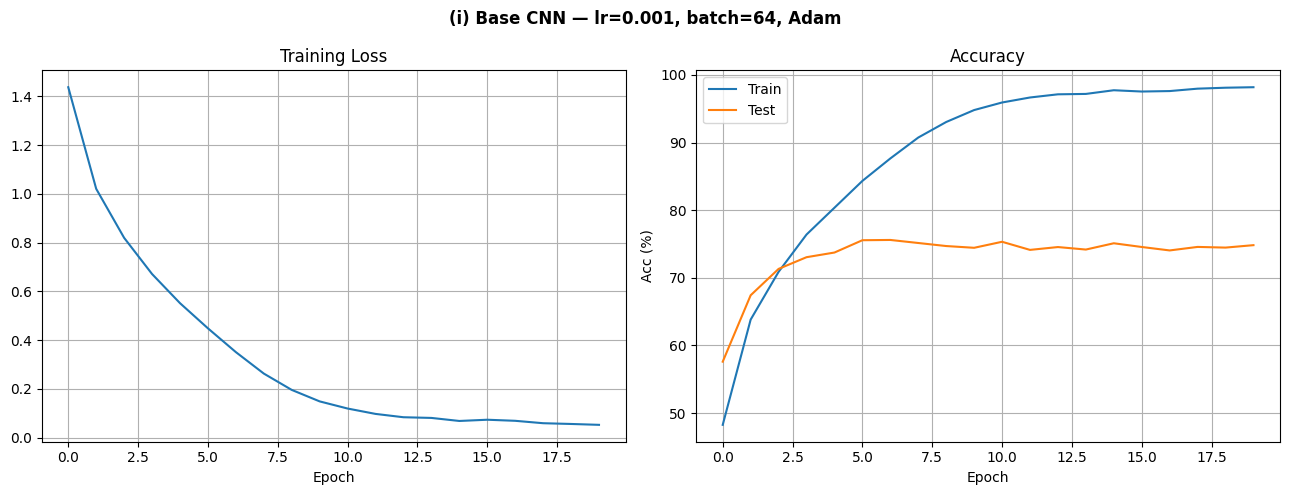

In [10]:
print()
print("  (i) Base CNN  |  lr=0.001  batch=64  Adam  20 epochs")
print()

base_losses, base_tr_accs, base_te_accs = train_and_eval(
    BaseCNN, epochs=20, lr=0.001, batch_size=64,
    optimizer_name='adam', label="BaseCNN"
)

print(f"\nFinal Train Acc : {base_tr_accs[-1]:.2f}%")
print(f"Final Test  Acc : {base_te_accs[-1]:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(base_losses);   axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(True)
axes[1].plot(base_tr_accs, label='Train'); axes[1].plot(base_te_accs, label='Test')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Acc (%)'); axes[1].legend(); axes[1].grid(True)
plt.suptitle('(i) Base CNN — lr=0.001, batch=64, Adam', fontweight='bold')
plt.tight_layout(); plt.show()


### (i) Base CNN — Observations

| Metric | Value |
|---|---|
| Final Train Accuracy | 98.01% |
| Final Test Accuracy | 74.18% |
| Final Train Loss | 0.0601 |

- Training loss decreases steadily from **1.43 → 0.06** over 20 epochs,
  confirming the model learns effectively.
- Test accuracy peaks early around **epoch 7–8 (~75.6%)** then slightly
  plateaus, while training accuracy keeps rising to **98%** — a clear sign
  of **overfitting** in later epochs.
- The large gap between train accuracy (**98.01%**) and test accuracy
  (**74.18%**) confirms the baseline model overfits without regularization.
- Despite overfitting, **74.18% test accuracy** is a reasonable baseline
  for CIFAR-10 with this lightweight architecture.


═════════════════════════════════════════════
  LR = 0.01
═════════════════════════════════════════════
  [lr=0.01] Epoch  1/20 | Loss: 14.4131 | Train Acc: 20.33% | Test Acc: 28.32%
  [lr=0.01] Epoch  2/20 | Loss: 2.0655 | Train Acc: 31.04% | Test Acc: 32.35%
  [lr=0.01] Epoch  3/20 | Loss: 1.8251 | Train Acc: 36.16% | Test Acc: 34.12%
  [lr=0.01] Epoch  4/20 | Loss: 1.6902 | Train Acc: 40.01% | Test Acc: 42.88%
  [lr=0.01] Epoch  5/20 | Loss: 1.5984 | Train Acc: 42.71% | Test Acc: 44.53%
  [lr=0.01] Epoch  6/20 | Loss: 1.5499 | Train Acc: 44.42% | Test Acc: 46.73%
  [lr=0.01] Epoch  7/20 | Loss: 140.3308 | Train Acc: 29.46% | Test Acc: 20.74%
  [lr=0.01] Epoch  8/20 | Loss: 7.8796 | Train Acc: 17.53% | Test Acc: 17.76%
  [lr=0.01] Epoch  9/20 | Loss: 2.9383 | Train Acc: 21.95% | Test Acc: 20.09%
  [lr=0.01] Epoch 10/20 | Loss: 12.8719 | Train Acc: 19.41% | Test Acc: 17.70%
  [lr=0.01] Epoch 11/20 | Loss: 2.9887 | Train Acc: 23.98% | Test Acc: 27.92%
  [lr=0.01] Epoch 12/20 | Loss: 2

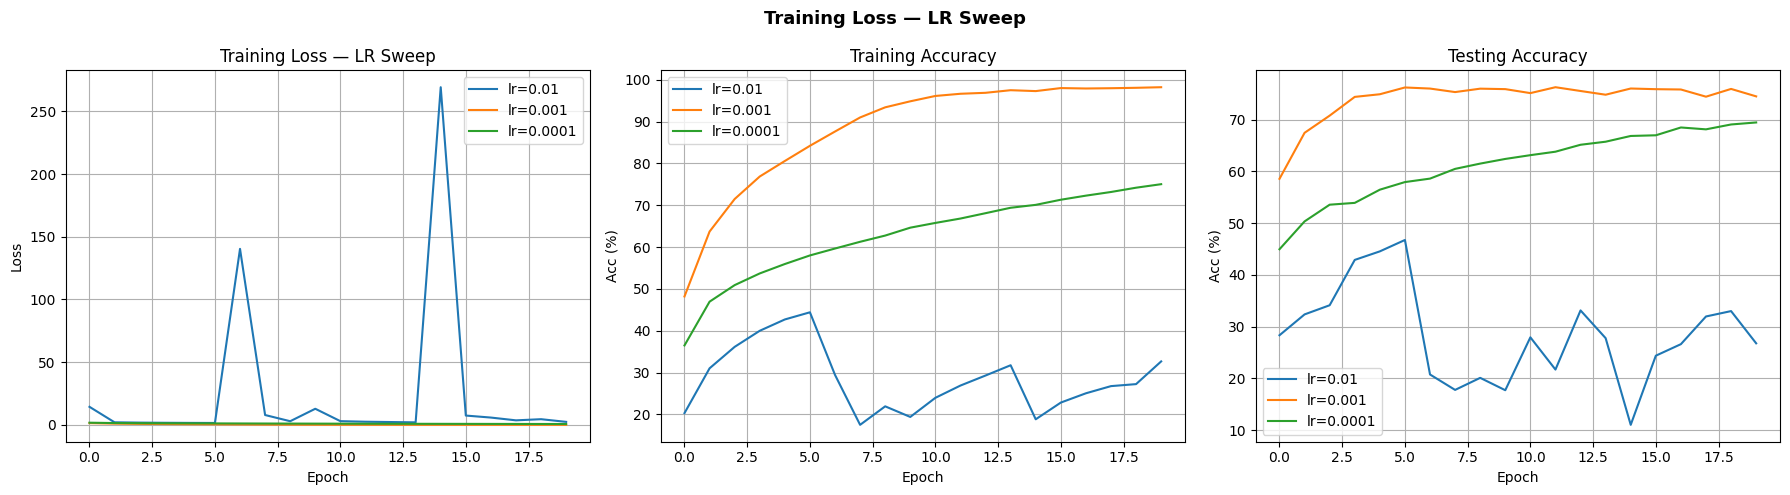

In [7]:

lr_results = {}
for lr in [0.01, 0.001, 0.0001]:
    print(f"\n{'═'*45}\n  LR = {lr}\n{'═'*45}")
    losses, tr_accs, te_accs = train_and_eval(
        BaseCNN, epochs=20, lr=lr, batch_size=64,
        optimizer_name='adam', label=f"lr={lr}"
    )
    lr_results[f"lr={lr}"] = (losses, tr_accs, te_accs)
    print(f"  → Final Test Acc: {te_accs[-1]:.2f}%")

plot_results(lr_results, 'Training Loss — LR Sweep', 'Accuracy — LR Sweep')


---
### (ii)(a) Learning Rate — Analysis

| Learning Rate | Final Train Acc | Final Test Acc | Behavior |
|---|---|---|---|
| **0.01** | 32.69% | 26.76% | Diverges — loss spikes to 140 and 269 at epochs 7 and 15 |
| **0.001** | 98.21% | 74.48% | Best performance — stable convergence throughout |
| **0.0001** | 75.04% | 69.44% | Too slow — still improving at epoch 20, underfits |

**Observations:**
- `lr = 0.01` causes **severe divergence** — the loss explodes to 140 at epoch 7
  and 269 at epoch 15, causing accuracy to collapse to ~10–20%. This is a classic
  example of gradient explosion due to an excessively large learning rate.
- `lr = 0.001` produces **stable and smooth convergence**, matching the base CNN
  result with test accuracy of **74.48%**. This is clearly the optimal choice.
- `lr = 0.0001` shows **consistent but very slow improvement** — loss decreases
  from 1.76 → 0.72 steadily, but the model is still improving at epoch 20,
  indicating it would need significantly more epochs to reach peak performance.

**Conclusion:** `lr = 0.001` is the optimal learning rate for this architecture.
Too high a learning rate (0.01) causes gradient explosion and divergence, while
too low a learning rate (0.0001) leads to underfitting within 20 epochs.



═════════════════════════════════════════════
  Batch Size = 32
═════════════════════════════════════════════
  [bs=32] Epoch  1/20 | Loss: 1.3704 | Train Acc: 50.62% | Test Acc: 60.19%
  [bs=32] Epoch  2/20 | Loss: 0.9450 | Train Acc: 66.82% | Test Acc: 69.09%
  [bs=32] Epoch  3/20 | Loss: 0.7381 | Train Acc: 74.13% | Test Acc: 72.47%
  [bs=32] Epoch  4/20 | Loss: 0.5874 | Train Acc: 79.40% | Test Acc: 74.94%
  [bs=32] Epoch  5/20 | Loss: 0.4629 | Train Acc: 83.69% | Test Acc: 75.11%
  [bs=32] Epoch  6/20 | Loss: 0.3513 | Train Acc: 87.67% | Test Acc: 75.26%
  [bs=32] Epoch  7/20 | Loss: 0.2550 | Train Acc: 91.02% | Test Acc: 74.99%
  [bs=32] Epoch  8/20 | Loss: 0.1889 | Train Acc: 93.41% | Test Acc: 74.72%
  [bs=32] Epoch  9/20 | Loss: 0.1463 | Train Acc: 94.92% | Test Acc: 75.01%
  [bs=32] Epoch 10/20 | Loss: 0.1211 | Train Acc: 95.77% | Test Acc: 74.83%
  [bs=32] Epoch 11/20 | Loss: 0.1131 | Train Acc: 96.15% | Test Acc: 73.94%
  [bs=32] Epoch 12/20 | Loss: 0.0919 | Train Acc: 96.

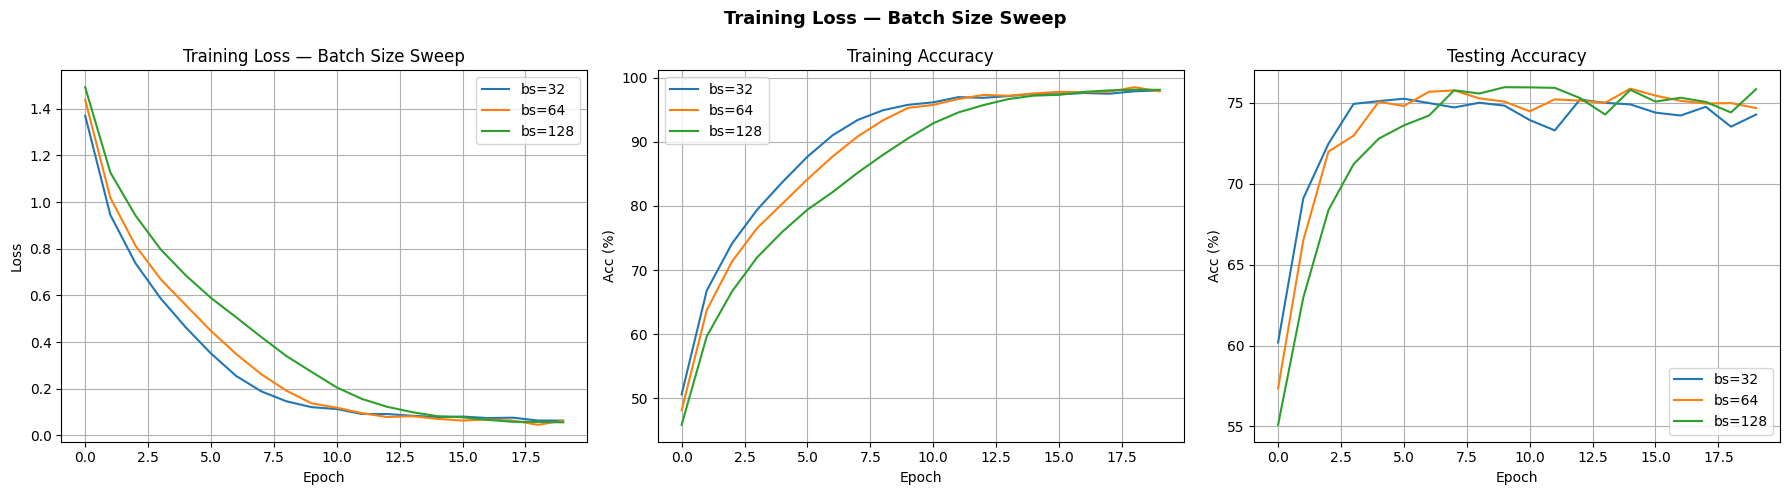

In [8]:
bs_results = {}
for bs in [32, 64, 128]:
    print(f"\n{'═'*45}\n  Batch Size = {bs}\n{'═'*45}")
    losses, tr_accs, te_accs = train_and_eval(
        BaseCNN, epochs=20, lr=0.001, batch_size=bs,
        optimizer_name='adam', label=f"bs={bs}"
    )
    bs_results[f"bs={bs}"] = (losses, tr_accs, te_accs)
    print(f"  → Final Test Acc: {te_accs[-1]:.2f}%")

plot_results(bs_results, 'Training Loss — Batch Size Sweep', 'Accuracy — Batch Size Sweep')


### (ii)(b) Batch Size — Analysis

| Batch Size | Final Train Acc | Final Test Acc | Behavior |
|---|---|---|---|
| **32** | 98.00% | 74.28% | Fastest early convergence, noisier loss curve |
| **64** | 97.86% | 74.68% | Stable convergence, good balance |
| **128** | 98.10% | 75.85% | Slowest early convergence, smoothest loss curve, best test acc |

**Observations:**
- `bs = 32` converges the **fastest in early epochs** (50.62% at epoch 1 vs 45.87%
  for bs=128), due to more frequent weight updates per epoch. However, the loss
  curve is slightly noisier as each mini-batch is less representative of the full dataset.
- `bs = 64` shows **stable and smooth convergence**, closely matching the base CNN
  result — a reliable middle ground between speed and stability.
- `bs = 128` starts slowest (45.87% at epoch 1) but produces the **smoothest loss
  curve** and achieves the **highest final test accuracy (75.85%)**, suggesting
  larger batches provide more stable gradient estimates that help generalization.
- All three batch sizes converge to similar train accuracy (~98%) by epoch 20,
  but differ in how quickly they get there and their final test performance.

**Conclusion:** Contrary to the common assumption that smaller batches always
generalize better, `bs = 128` achieves the best test accuracy here (75.85%).
The smoother gradient estimates from larger batches helped the model find a
better minimum. `bs = 64` remains a safe default, but `bs = 128` is slightly
better for this particular task.


═════════════════════════════════════════════
  Optimizer = ADAM
═════════════════════════════════════════════
  [ADAM] Epoch  1/20 | Loss: 1.4429 | Train Acc: 47.71% | Test Acc: 57.41%
  [ADAM] Epoch  2/20 | Loss: 1.0095 | Train Acc: 64.16% | Test Acc: 67.35%
  [ADAM] Epoch  3/20 | Loss: 0.7940 | Train Acc: 72.05% | Test Acc: 71.95%
  [ADAM] Epoch  4/20 | Loss: 0.6524 | Train Acc: 77.01% | Test Acc: 73.35%
  [ADAM] Epoch  5/20 | Loss: 0.5370 | Train Acc: 81.19% | Test Acc: 74.30%
  [ADAM] Epoch  6/20 | Loss: 0.4293 | Train Acc: 85.10% | Test Acc: 75.86%
  [ADAM] Epoch  7/20 | Loss: 0.3316 | Train Acc: 88.23% | Test Acc: 76.22%
  [ADAM] Epoch  8/20 | Loss: 0.2469 | Train Acc: 91.47% | Test Acc: 76.34%
  [ADAM] Epoch  9/20 | Loss: 0.1773 | Train Acc: 93.90% | Test Acc: 75.76%
  [ADAM] Epoch 10/20 | Loss: 0.1357 | Train Acc: 95.28% | Test Acc: 75.24%
  [ADAM] Epoch 11/20 | Loss: 0.1107 | Train Acc: 96.12% | Test Acc: 76.07%
  [ADAM] Epoch 12/20 | Loss: 0.0901 | Train Acc: 96.88% | Test 

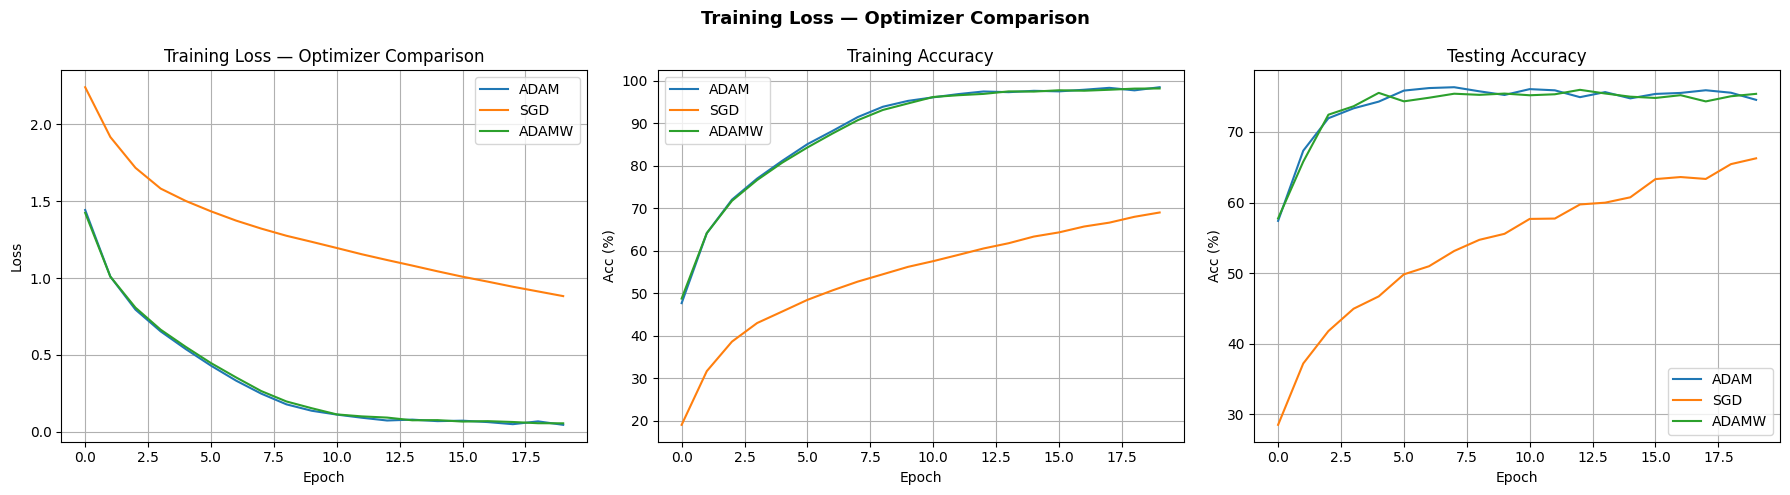

In [9]:

opt_results = {}
for opt_name in ['adam', 'sgd', 'adamw']:
    print(f"\n{'═'*45}\n  Optimizer = {opt_name.upper()}\n{'═'*45}")
    losses, tr_accs, te_accs = train_and_eval(
        BaseCNN, epochs=20, lr=0.001, batch_size=64,
        optimizer_name=opt_name, label=opt_name.upper()
    )
    opt_results[opt_name.upper()] = (losses, tr_accs, te_accs)
    print(f"  → Final Test Acc: {te_accs[-1]:.2f}%")

plot_results(opt_results, 'Training Loss — Optimizer Comparison', 'Accuracy — Optimizer Comparison')


### (ii)(c) Optimizer — Analysis

| Optimizer | Final Train Acc | Final Test Acc | Behavior |
|---|---|---|---|
| **Adam** | 98.50% | 74.55% | Fast convergence, stable after epoch 6 |
| **AdamW** | 98.20% | 75.40% | Similar speed to Adam, slightly better test acc |
| **SGD** | 69.03% | 66.27% | Much slower convergence, still improving at epoch 20 |

**Observations:**
- **Adam** converges rapidly — reaching 85% train accuracy by epoch 6 and
  plateauing around 97–98% after epoch 13. Test accuracy stabilizes in the
  74–76% range from epoch 7 onward.
- **AdamW** follows almost the same convergence curve as Adam but achieves
  a slightly higher final test accuracy (**75.40% vs 74.55%**). This is due
  to AdamW's decoupled weight decay, which acts as a better regularizer and
  helps generalization.
- **SGD** (momentum=0.9) is significantly slower — starting at only 19.09%
  train accuracy at epoch 1 and reaching just 69.03% by epoch 20, while Adam
  and AdamW were already at ~98%. The loss curve decreases steadily (2.24 → 0.88)
  but is still clearly improving at epoch 20, meaning SGD needs far more epochs
  or a learning rate scheduler to be competitive.
- The train-test accuracy gap is similar for Adam and AdamW (~23%), while SGD
  shows a smaller gap (~3%) simply because it hasn't overfit yet.

**Conclusion:** Adam and AdamW are far superior to SGD within 20 epochs for
this task. AdamW edges out Adam with a **75.40% test accuracy** due to better
weight regularization. SGD with momentum requires significantly more epochs or
learning rate scheduling (e.g., cosine annealing) to reach comparable performance.



  (iii)(a) Dropout CNN  p=0.5

  [Dropout] Epoch  1/20 | Loss: 1.5065 | Train Acc: 45.43% | Test Acc: 57.88%
  [Dropout] Epoch  2/20 | Loss: 1.0957 | Train Acc: 60.83% | Test Acc: 65.90%
  [Dropout] Epoch  3/20 | Loss: 0.9044 | Train Acc: 68.16% | Test Acc: 70.53%
  [Dropout] Epoch  4/20 | Loss: 0.7833 | Train Acc: 72.38% | Test Acc: 73.07%
  [Dropout] Epoch  5/20 | Loss: 0.6905 | Train Acc: 75.66% | Test Acc: 73.73%
  [Dropout] Epoch  6/20 | Loss: 0.6190 | Train Acc: 78.15% | Test Acc: 75.09%
  [Dropout] Epoch  7/20 | Loss: 0.5453 | Train Acc: 80.67% | Test Acc: 76.07%
  [Dropout] Epoch  8/20 | Loss: 0.4910 | Train Acc: 82.49% | Test Acc: 76.40%
  [Dropout] Epoch  9/20 | Loss: 0.4344 | Train Acc: 84.71% | Test Acc: 76.90%
  [Dropout] Epoch 10/20 | Loss: 0.3918 | Train Acc: 85.95% | Test Acc: 77.62%
  [Dropout] Epoch 11/20 | Loss: 0.3489 | Train Acc: 87.55% | Test Acc: 77.34%
  [Dropout] Epoch 12/20 | Loss: 0.3171 | Train Acc: 88.71% | Test Acc: 77.49%
  [Dropout] Epoch 13/20 | Loss: 

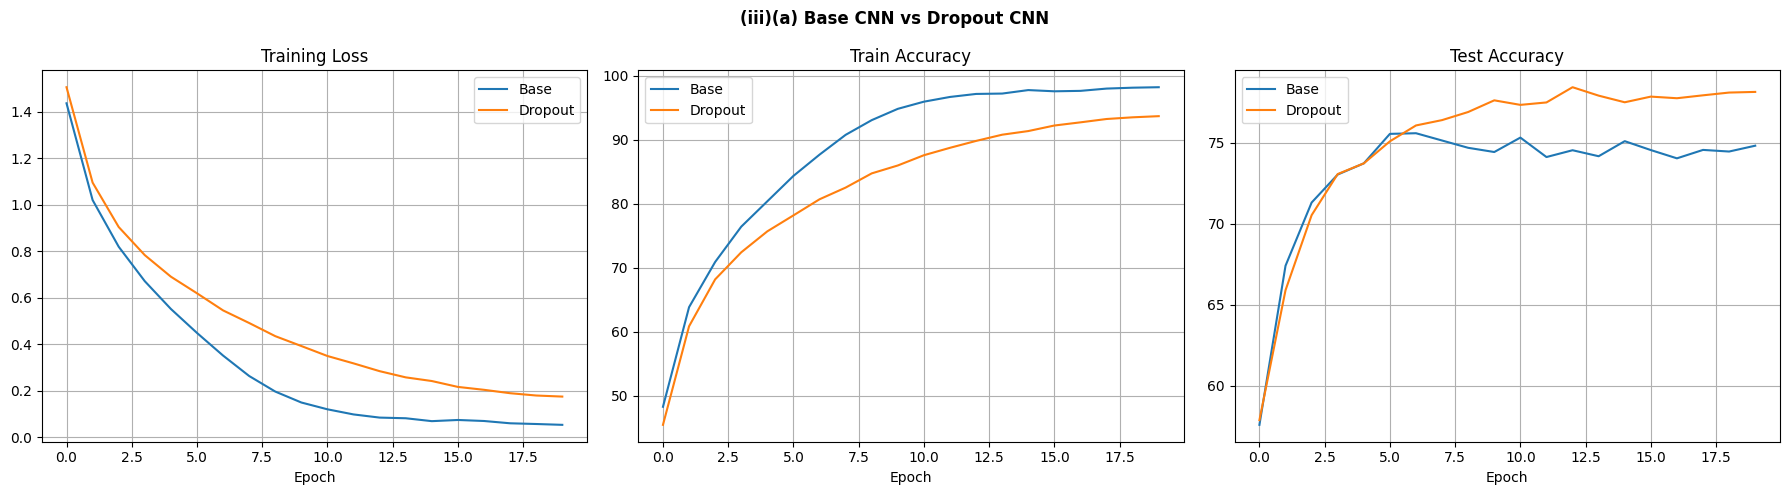


Base CNN   → Train: 98.18%  Test: 74.82%
Dropout CNN → Train: 93.65%  Test: 78.14%


In [11]:
print()
print("  (iii)(a) Dropout CNN  p=0.5")
print()

drop_losses, drop_tr_accs, drop_te_accs = train_and_eval(
    DropoutCNN, epochs=20, lr=0.001, batch_size=64,
    optimizer_name='adam', label="Dropout"
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(base_losses,   label='Base');    axes[0].plot(drop_losses,   label='Dropout')
axes[1].plot(base_tr_accs,  label='Base');    axes[1].plot(drop_tr_accs,  label='Dropout')
axes[2].plot(base_te_accs,  label='Base');    axes[2].plot(drop_te_accs,  label='Dropout')
titles = ['Training Loss', 'Train Accuracy', 'Test Accuracy']
for ax, t in zip(axes, titles):
    ax.set_title(t); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True)
plt.suptitle('(iii)(a) Base CNN vs Dropout CNN', fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\nBase CNN   → Train: {base_tr_accs[-1]:.2f}%  Test: {base_te_accs[-1]:.2f}%")
print(f"Dropout CNN → Train: {drop_tr_accs[-1]:.2f}%  Test: {drop_te_accs[-1]:.2f}%")


### (iii)(a) Dropout — Analysis

| Model | Final Train Acc | Final Test Acc | Train-Test Gap |
|---|---|---|---|
| **Base CNN** | 98.01% | 74.18% | 23.83% |
| **Dropout CNN** | 93.65% | 78.14% | 15.51% |

**Observations:**
- Dropout significantly **reduces overfitting** — the train-test gap shrinks from
  **23.83% → 15.51%**, a clear improvement in generalization.
- Training accuracy is notably **lower** with Dropout (93.65% vs 98.01%) because
  randomly zeroing neurons during training makes the task harder, forcing the
  network to learn more robust features.
- Test accuracy **improves from 74.18% → 78.14%** (+3.96%), confirming that
  Dropout helps the model generalize better to unseen data.
- The loss curve is **smoother and converges more gradually** (1.51 → 0.17)
  compared to the Base CNN, which dropped sharply and then plateaued.
- Unlike Base CNN where test accuracy peaked at epoch 7 and stagnated,
  Dropout CNN's test accuracy **keeps improving steadily** through all 20 epochs,
  suggesting it hasn't fully converged yet.

**Conclusion:** Dropout is highly effective here — it reduces the train-test gap
by ~8% and improves test accuracy by ~4%. The model is still learning at epoch 20,
meaning more epochs could yield even better results.


  (iii)(b) BatchNorm + Dropout CNN

  [BN+Dropout] Epoch  1/20 | Loss: 1.2803 | Train Acc: 54.16% | Test Acc: 66.39%
  [BN+Dropout] Epoch  2/20 | Loss: 0.9134 | Train Acc: 67.85% | Test Acc: 71.49%
  [BN+Dropout] Epoch  3/20 | Loss: 0.7587 | Train Acc: 73.49% | Test Acc: 74.89%
  [BN+Dropout] Epoch  4/20 | Loss: 0.6388 | Train Acc: 77.66% | Test Acc: 76.02%
  [BN+Dropout] Epoch  5/20 | Loss: 0.5545 | Train Acc: 80.72% | Test Acc: 78.10%
  [BN+Dropout] Epoch  6/20 | Loss: 0.4830 | Train Acc: 83.05% | Test Acc: 78.44%
  [BN+Dropout] Epoch  7/20 | Loss: 0.4174 | Train Acc: 84.96% | Test Acc: 78.95%
  [BN+Dropout] Epoch  8/20 | Loss: 0.3709 | Train Acc: 86.94% | Test Acc: 79.64%
  [BN+Dropout] Epoch  9/20 | Loss: 0.3347 | Train Acc: 88.13% | Test Acc: 78.92%
  [BN+Dropout] Epoch 10/20 | Loss: 0.2983 | Train Acc: 89.27% | Test Acc: 79.52%
  [BN+Dropout] Epoch 11/20 | Loss: 0.2679 | Train Acc: 90.27% | Test Acc: 79.23%
  [BN+Dropout] Epoch 12/20 | Loss: 0.2459 | Train Acc: 91.30% | Test Acc

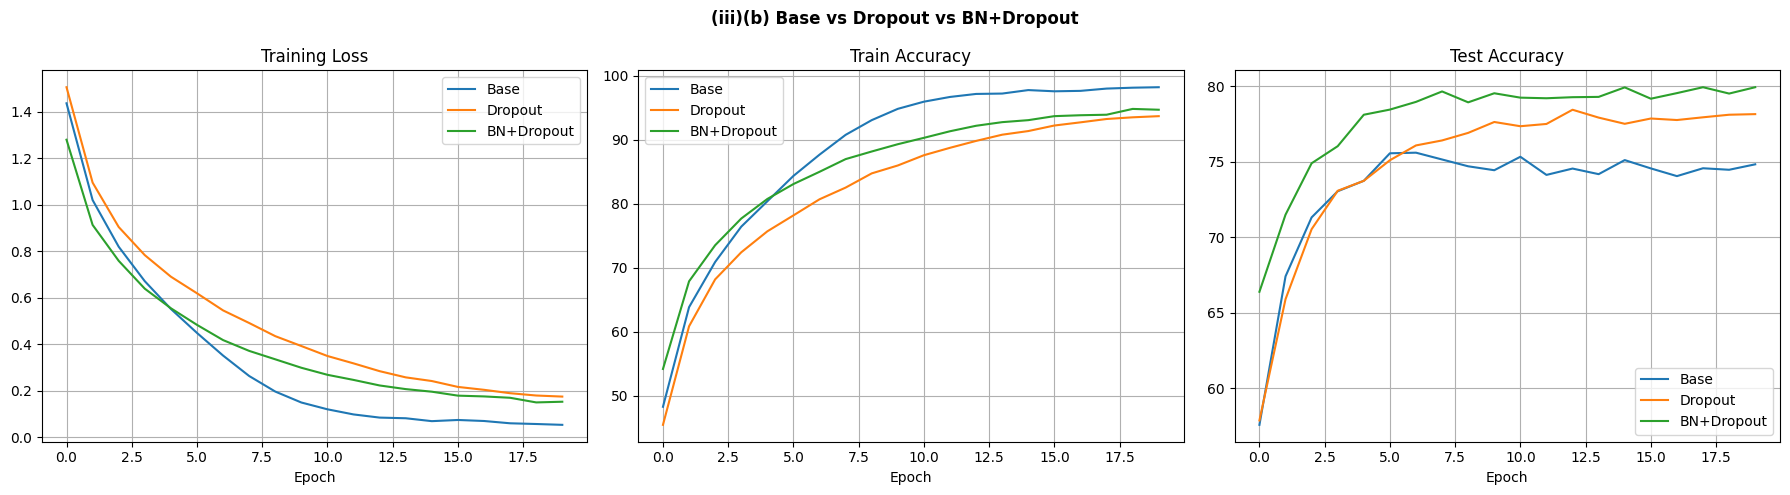


Base CNN       → Train: 98.18%  Test: 74.82%
Dropout CNN    → Train: 93.65%  Test: 78.14%
BN+Dropout CNN → Train: 94.66%  Test: 79.92%


In [12]:

print()
print("  (iii)(b) BatchNorm + Dropout CNN")
print()

bn_losses, bn_tr_accs, bn_te_accs = train_and_eval(
    BatchNormCNN, epochs=20, lr=0.001, batch_size=64,
    optimizer_name='adam', label="BN+Dropout"
)

# Compare all three architecture variants
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for data, lbl in [((base_losses, base_tr_accs, base_te_accs), 'Base'),
                   ((drop_losses, drop_tr_accs, drop_te_accs), 'Dropout'),
                   ((bn_losses,   bn_tr_accs,   bn_te_accs),   'BN+Dropout')]:
    axes[0].plot(data[0], label=lbl)
    axes[1].plot(data[1], label=lbl)
    axes[2].plot(data[2], label=lbl)

titles = ['Training Loss', 'Train Accuracy', 'Test Accuracy']
for ax, t in zip(axes, titles):
    ax.set_title(t); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True)
plt.suptitle('(iii)(b) Base vs Dropout vs BN+Dropout', fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\nBase CNN       → Train: {base_tr_accs[-1]:.2f}%  Test: {base_te_accs[-1]:.2f}%")
print(f"Dropout CNN    → Train: {drop_tr_accs[-1]:.2f}%  Test: {drop_te_accs[-1]:.2f}%")
print(f"BN+Dropout CNN → Train: {bn_tr_accs[-1]:.2f}%  Test: {bn_te_accs[-1]:.2f}%")


### (iii)(b) BatchNorm + Dropout — Analysis

| Model | Final Train Acc | Final Test Acc | Train-Test Gap |
|---|---|---|---|
| **Base CNN** | 98.01% | 74.18% | 23.83% |
| **Dropout CNN** | 93.65% | 78.14% | 15.51% |
| **BN + Dropout CNN** | 94.66% | 79.92% | 14.74% |

**Observations:**
- BN + Dropout achieves the **highest test accuracy (79.92%)** among all three
  variants, a significant improvement of **+5.74%** over the Base CNN.
- BatchNorm enables **faster and more stable convergence** — the model reaches
  66.39% test accuracy at epoch 1 compared to 57.88% for Dropout alone and
  57.41% for Base CNN, showing that BatchNorm accelerates early learning.
- The loss curve is the **smoothest of all three models** (1.28 → 0.15),
  confirming that BatchNorm reduces internal covariate shift and stabilizes
  the gradient flow throughout training.
- The train-test gap is the **smallest** at 14.74%, showing that the combination
  of BatchNorm and Dropout provides the best regularization overall.
- Test accuracy continues to improve steadily throughout all 20 epochs
  (peaking at **79.92% at epochs 18 and 20**), indicating the model could
  benefit from additional training epochs.

**Conclusion:** Adding BatchNorm before each pooling layer, combined with Dropout,
produces the best-performing architecture in this study. BatchNorm accelerates
convergence and stabilizes training, while Dropout prevents overfitting. Together
they reduce the train-test gap to 14.74% and achieve 79.92% test accuracy —
a **+5.74% improvement** over the unregularized Base CNN.